# E-commerce Sales Analytics: Complete Business Analysis

This notebook presents a full business-focused data analytics workflow using a realistic synthetic e-commerce dataset. The project covers data generation, cleaning, validation, exploratory data analysis, visualization, insight development, and actionable recommendations.

**Business domain selected:** E-commerce Sales.

This domain was selected because it creates a strong portfolio use case: revenue analysis, customer segmentation, product performance, sales channels, regional trends, discounts, returns, fulfillment, and customer satisfaction can all be analyzed together.

## Business Objective

The business wants to understand what drives revenue, which products and customer groups perform best, where returns are concentrated, and how delivery performance affects customer satisfaction. The goal is to turn transactional data into practical decisions for growth, retention, and operational improvement.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / 'scripts'))

from analysis import (
    DATASET_PATH,
    CHART_DIR,
    REPORT_PATH,
    generate_dataset,
    clean_data,
    create_visuals,
    build_insights,
    write_report,
)

pd.set_option('display.max_columns', 30)
sns.set_theme(style='whitegrid', palette='Set2')

## Step 1: Dataset Generation

The dataset contains exactly 10,000 raw rows and is designed to resemble real e-commerce transaction data. It includes a date column, categorical fields, numerical fields, missing values, duplicates, and outliers.

Realistic data quality issues were included intentionally because most analyst work involves cleaning imperfect data before business interpretation.

In [2]:
raw_df = generate_dataset(DATASET_PATH, n_rows=10_000)
raw_df.shape

(10000, 15)

In [3]:
raw_df.head()

,order_id,customer_id,order_date,region,customer_segment,product_category,sales_channel,payment_method,quantity,unit_price,discount_pct,shipping_fee,delivery_days,customer_rating,returned
0,ORD-106252,CUST-10146,2025-04-20,North,New,Home & Kitchen,Website,Credit Card,2,49.04,0.016,5.08,4,4.5,0
1,ORD-104684,CUST-11076,2024-12-13,West,Returning,Fashion,Website,Credit Card,1,53.62,0.241,14.25,4,4.4,0
2,ORD-101731,CUST-12944,2024-05-29,Central,Loyal,Fashion,Social Commerce,Credit Card,2,112.61,0.088,7.24,5,4.4,0
3,ORD-104742,CUST-10116,2024-12-16,East,Loyal,Beauty,Website,Credit Card,1,100.45,0.190,10.87,5,3.8,0
4,ORD-104521,CUST-14355,2024-12-04,Central,New,Fashion,Mobile App,Cash on Delivery,6,49.60,0.081,0.91,7,4.2,0


## Step 2: Initial Data Review

Before cleaning, we inspect the dataset structure, missing values, duplicate records, and summary statistics. This helps identify the type of treatment needed for each column.

In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   customer_id       10000 non-null  object 
 2   order_date        10000 non-null  object 
 3   region            9770 non-null   object 
 4   customer_segment  10000 non-null  object 
 5   product_category  10000 non-null  object 
 6   sales_channel     9886 non-null   object 
 7   payment_method    9774 non-null   object 
 8   quantity          10000 non-null  int64  
 9   unit_price        10000 non-null  float64
 10  discount_pct      9574 non-null   float64
 11  shipping_fee      10000 non-null  float64
 12  delivery_days     10000 non-null  int64  
 13  customer_rating   9420 non-null   float64
 14  returned          10000 non-null  int64  
dtypes: float64(4), int64(3), object(8)
memory usage: 1.1+ MB


In [5]:
raw_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,10000,9980,ORD-107040,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,10000,4351,CUST-12771,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,10000,731,2024-11-06,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,9770,5,North,2379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,10000,4,Returning,3653,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_category,10000,6,Fashion,2366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales_channel,9886,4,Website,4168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,9774,5,Credit Card,3068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,10000.0,NaN,NaN,NaN,2.2475,3.158392,1.0,1.0,2.0,3.0,54.0
unit_price,10000.0,NaN,NaN,NaN,101.903022,114.510922,8.02,42.7875,67.59,122.6125,2653.78


In [6]:
missing_before = raw_df.isna().sum().sort_values(ascending=False)
missing_before[missing_before > 0]

customer_rating    580
discount_pct       426
region             230
payment_method     226
sales_channel      114
dtype: int64

In [7]:
raw_df.duplicated().sum()

np.int64(20)

## Step 3: Data Cleaning

The cleaning process includes:

- Removing exact duplicate rows.
- Converting `order_date` to a datetime type.
- Converting numeric fields to numeric data types.
- Filling missing categorical values with the mode.
- Filling missing discounts with 0 because a blank discount usually means no promotion was recorded.
- Filling missing customer ratings with the median to avoid skewing satisfaction results.
- Detecting and capping numeric outliers using the IQR method.
- Recalculating `total_amount` after numeric fields are cleaned.
- Creating month and year fields for trend analysis.

In [8]:
clean_df, diagnostics = clean_data(raw_df)
clean_df.shape

(9980, 18)

In [9]:
pd.Series(diagnostics['missing_after']).sum()

np.int64(0)

In [10]:
pd.DataFrame(diagnostics['outlier_summary']).T

,count,lower_bound,upper_bound
quantity,115.0,-2.0000,6.0000
unit_price,786.0,-76.8875,242.3125
shipping_fee,216.0,-7.5750,20.5450
delivery_days,288.0,0.0000,8.0000
total_amount,639.0,-138.3075,420.4925


## Step 4: Data Validation

After cleaning, the dataset is validated against business logic. Quantities and prices should be positive, discounts should remain within a realistic range, ratings should be between 1 and 5, and return flags should be binary.

In [11]:
pd.Series(diagnostics['validation_checks'])

no_missing_values    True
positive_quantity    True
positive_prices      True
valid_discounts      True
valid_ratings        True
valid_return_flag    True
dtype: bool

In [12]:
clean_df.head()

,order_id,customer_id,order_date,region,customer_segment,product_category,sales_channel,payment_method,quantity,unit_price,discount_pct,shipping_fee,delivery_days,customer_rating,returned,total_amount,month,year
0,ORD-106252,CUST-10146,2025-04-20,North,New,Home & Kitchen,Website,Credit Card,2,49.04,0.016,5.08,4,4.5,0,101.59,2025-04,2025
1,ORD-104684,CUST-11076,2024-12-13,West,Returning,Fashion,Website,Credit Card,1,53.62,0.241,14.25,4,4.4,0,54.95,2024-12,2024
2,ORD-101731,CUST-12944,2024-05-29,Central,Loyal,Fashion,Social Commerce,Credit Card,2,112.61,0.088,7.24,5,4.4,0,212.64,2024-05,2024
3,ORD-104742,CUST-10116,2024-12-16,East,Loyal,Beauty,Website,Credit Card,1,100.45,0.190,10.87,5,3.8,0,92.23,2024-12,2024
4,ORD-104521,CUST-14355,2024-12-04,Central,New,Fashion,Mobile App,Cash on Delivery,6,49.60,0.081,0.91,7,4.2,0,274.40,2024-12,2024


## Step 5: Summary Statistics

Summary statistics provide a first read on transaction value, quantity, pricing, discounts, shipping fees, delivery time, ratings, and returns.

In [13]:
clean_df.describe().T

,count,mean,min,25%,50%,75%,max,std
order_date,9980,2025-01-17 17:20:01.923847680,2024-01-01 00:00:00,2024-07-27 00:00:00,2024-12-30 00:00:00,2025-07-26 00:00:00,2025-12-31 00:00:00,NaN
quantity,9980.0,2.037174,1.0,1.0,2.0,3.0,6.0,1.255959
unit_price,9980.0,92.449667,8.02,42.8125,67.59,122.6125,242.3125,67.73272
discount_pct,9980.0,0.092645,0.0,0.036,0.075,0.137,0.443,0.071847
shipping_fee,9980.0,6.987217,0.0,2.97,6.11,10.0,20.545,5.099576
delivery_days,9980.0,4.206513,1.0,3.0,4.0,5.0,8.0,1.751279
customer_rating,9980.0,4.272595,2.2,4.0,4.3,4.5,5.0,0.409416
returned,9980.0,0.043788,0.0,0.0,0.0,0.0,1.0,0.204632
total_amount,9980.0,160.731168,12.96,71.135,121.98,205.115,1454.38,139.184876
year,9980.0,2024.496894,2024.0,2024.0,2024.0,2025.0,2025.0,0.500015


In [14]:
clean_df.describe(include='object').T

,count,unique,top,freq
order_id,9980,9980,ORD-106252,1
customer_id,9980,4351,CUST-12771,9
region,9980,5,North,2604
customer_segment,9980,4,Returning,3646
product_category,9980,6,Fashion,2362
sales_channel,9980,4,Website,4270
payment_method,9980,5,Credit Card,3286
month,9980,24,2024-11,616


## Step 6: Univariate Analysis

Univariate analysis examines each key variable independently. This helps identify common order values, category mix, channel concentration, and customer segment distribution.

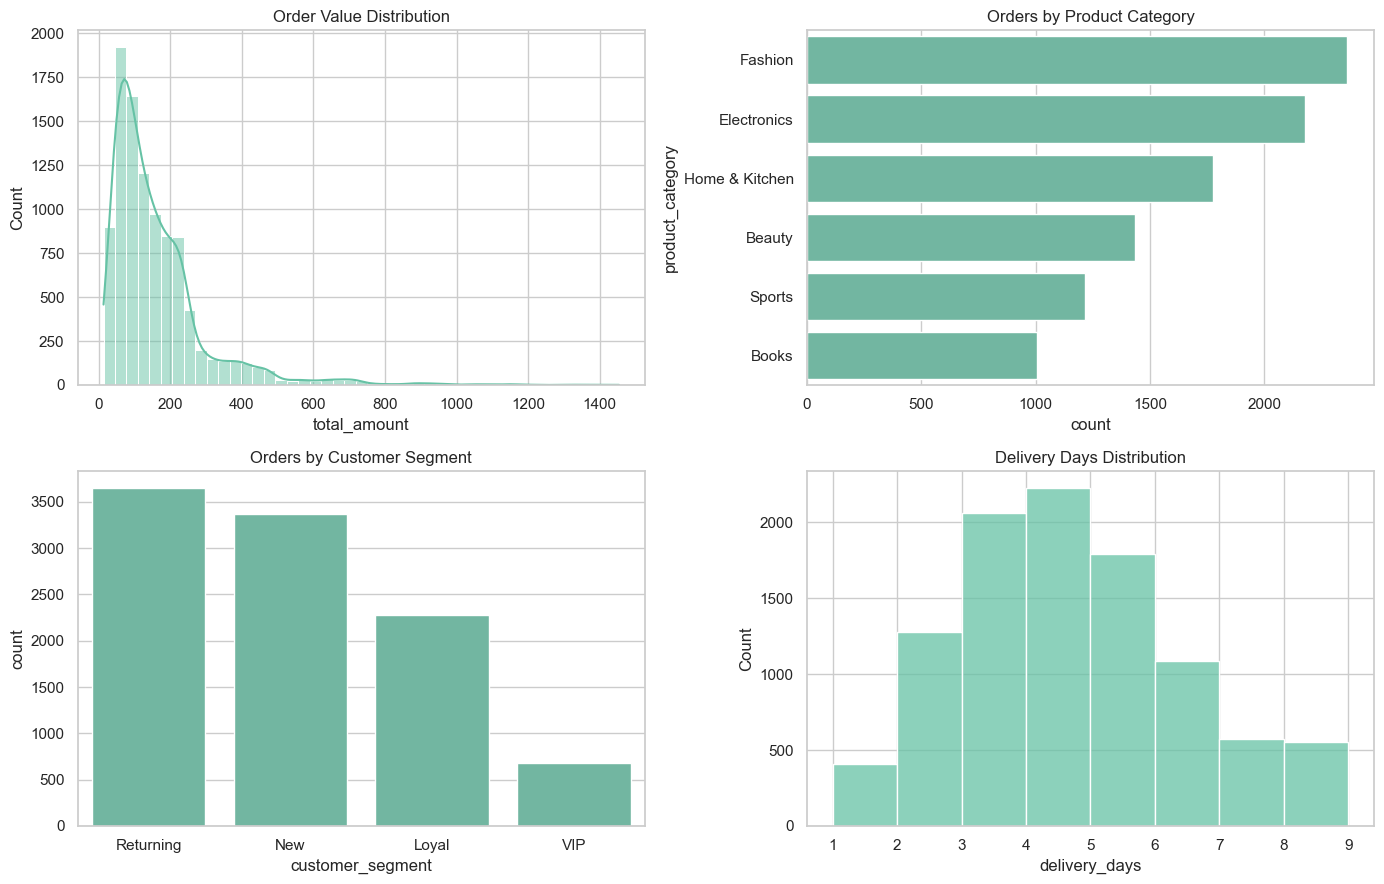

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.histplot(clean_df['total_amount'], bins=45, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Order Value Distribution')
sns.countplot(data=clean_df, y='product_category', order=clean_df['product_category'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Orders by Product Category')
sns.countplot(data=clean_df, x='customer_segment', order=clean_df['customer_segment'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title('Orders by Customer Segment')
sns.histplot(clean_df['delivery_days'], bins=range(1, int(clean_df['delivery_days'].max()) + 2), ax=axes[1, 1])
axes[1, 1].set_title('Delivery Days Distribution')
plt.tight_layout()

## Step 7: Bivariate Analysis

Bivariate analysis compares variables to understand relationships, such as category revenue, region revenue, return rate by category, and rating by channel.

In [16]:
category_revenue = clean_df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)
category_revenue

product_category
Electronics       615869.70
Fashion           293803.12
Home & Kitchen    292701.45
Sports            185447.92
Beauty            141034.69
Books              75240.18
Name: total_amount, dtype: float64

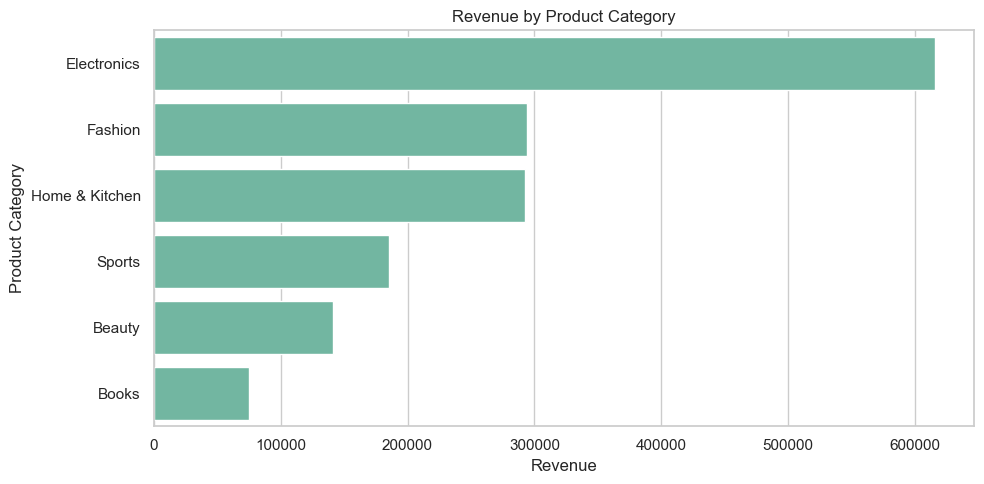

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(x=category_revenue.values, y=category_revenue.index)
plt.title('Revenue by Product Category')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()

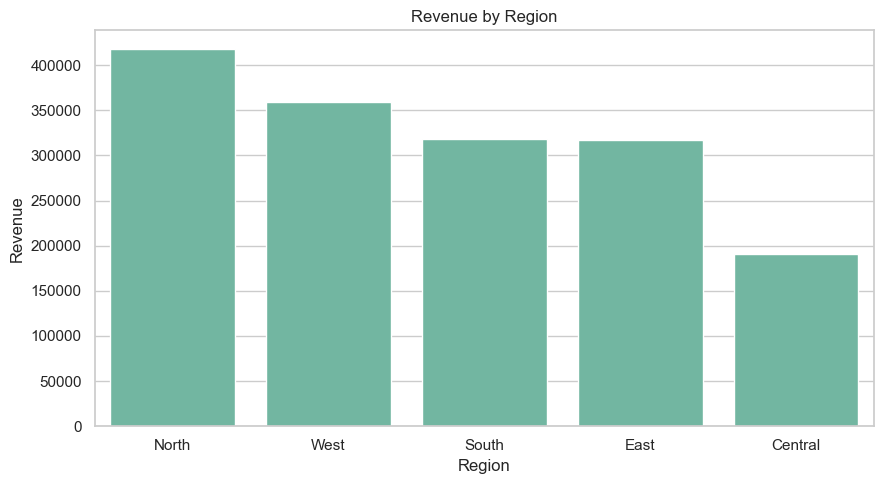

In [18]:
region_revenue = clean_df.groupby('region')['total_amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
sns.barplot(x=region_revenue.index, y=region_revenue.values)
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')
plt.tight_layout()

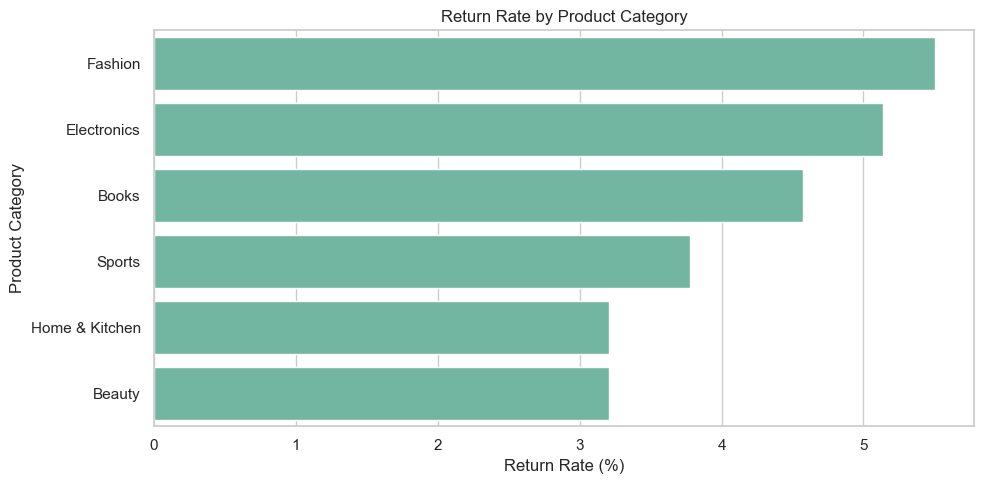

In [19]:
return_rate = clean_df.groupby('product_category')['returned'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10, 5))
sns.barplot(x=return_rate.values, y=return_rate.index)
plt.title('Return Rate by Product Category')
plt.xlabel('Return Rate (%)')
plt.ylabel('Product Category')
plt.tight_layout()

## Step 8: Correlation Analysis

Correlation analysis helps identify relationships among numeric variables. It is especially useful for seeing how order value relates to quantity, price, discounts, delivery time, ratings, and returns.

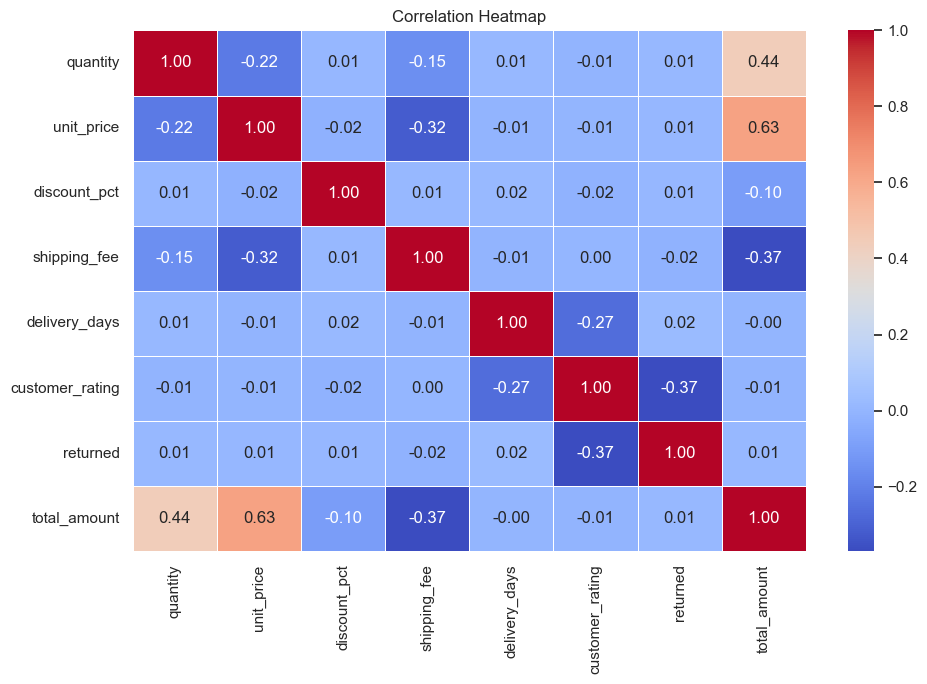

In [20]:
corr_columns = ['quantity', 'unit_price', 'discount_pct', 'shipping_fee', 'delivery_days', 'customer_rating', 'returned', 'total_amount']
plt.figure(figsize=(10, 7))
sns.heatmap(clean_df[corr_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()

## Step 9: Trend Analysis

Trend analysis evaluates sales performance over time. Monthly revenue and order volume help identify seasonality and campaign effects.

In [21]:
monthly = clean_df.groupby('month').agg(revenue=('total_amount', 'sum'), orders=('order_id', 'count')).reset_index()
monthly.head()

,month,revenue,orders
0,2024-01,56233.69,321
1,2024-02,53127.77,302
2,2024-03,52129.40,334
3,2024-04,59668.83,371
4,2024-05,73648.95,433


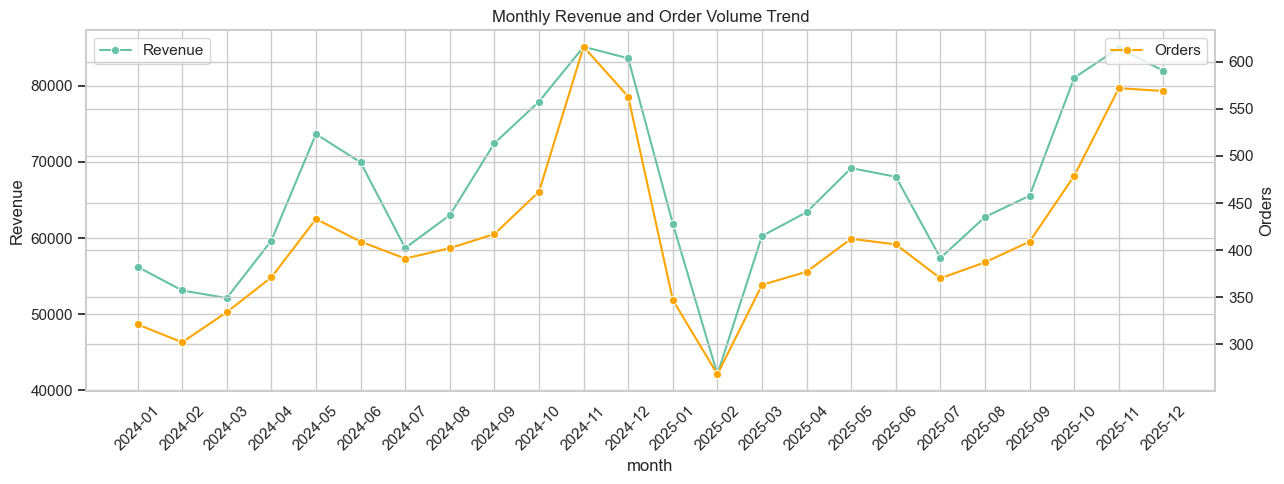

In [22]:
fig, ax1 = plt.subplots(figsize=(13, 5))
sns.lineplot(data=monthly, x='month', y='revenue', marker='o', ax=ax1, label='Revenue')
ax1.set_ylabel('Revenue')
ax1.tick_params(axis='x', rotation=45)
ax2 = ax1.twinx()
sns.lineplot(data=monthly, x='month', y='orders', marker='o', ax=ax2, color='orange', label='Orders')
ax2.set_ylabel('Orders')
plt.title('Monthly Revenue and Order Volume Trend')
fig.tight_layout()

## Step 10: Category, Channel, and Customer Segment Analysis

These views translate EDA into business decisions by showing where the company earns revenue, which customers matter most, and how purchase channels compare.

In [23]:
segment_summary = clean_df.groupby('customer_segment').agg(
    orders=('order_id', 'count'),
    revenue=('total_amount', 'sum'),
    avg_order_value=('total_amount', 'mean'),
    return_rate=('returned', 'mean'),
    avg_rating=('customer_rating', 'mean')
).sort_values('revenue', ascending=False)
segment_summary

,orders,revenue,avg_order_value,return_rate,avg_rating
customer_segment,,,,,
Returning,3646,589505.63,161.685581,0.042238,4.277345
New,3368,539732.32,160.253064,0.046318,4.266390
Loyal,2283,361412.77,158.306075,0.043364,4.267981
VIP,683,113446.34,166.100059,0.040996,4.293265


In [24]:
channel_summary = clean_df.groupby('sales_channel').agg(
    orders=('order_id', 'count'),
    revenue=('total_amount', 'sum'),
    avg_order_value=('total_amount', 'mean'),
    avg_rating=('customer_rating', 'mean')
).sort_values('revenue', ascending=False)
channel_summary

,orders,revenue,avg_order_value,avg_rating
sales_channel,,,,
Website,4270,696302.47,163.068494,4.271311
Mobile App,3357,531893.64,158.443146,4.272892
Marketplace,1771,282293.96,159.398058,4.280915
Social Commerce,582,93606.99,160.836753,4.254983


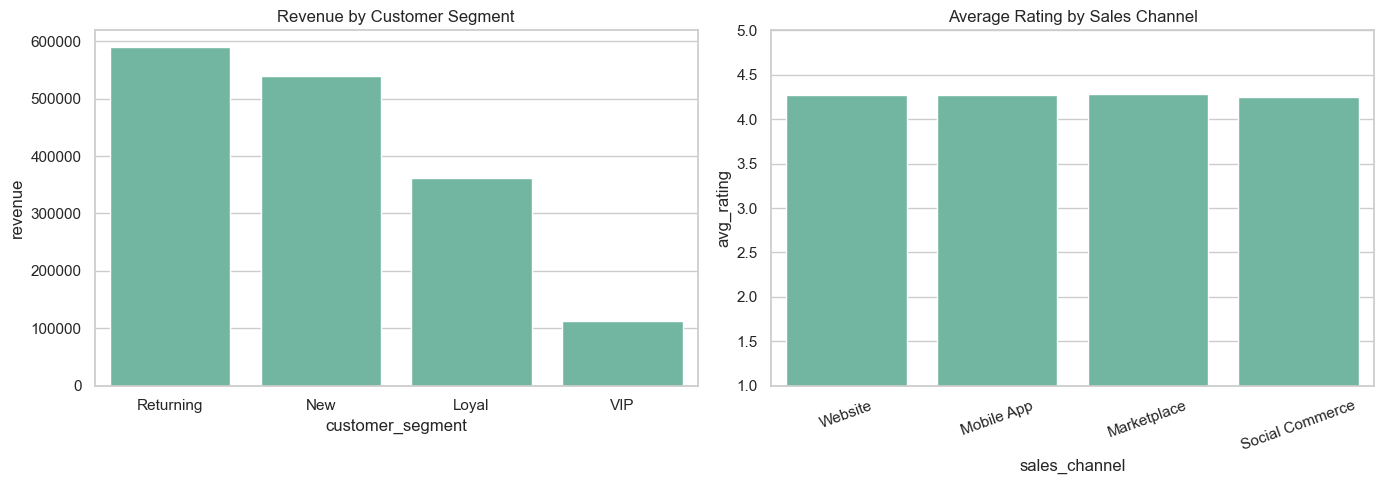

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=segment_summary.reset_index(), x='customer_segment', y='revenue', ax=axes[0])
axes[0].set_title('Revenue by Customer Segment')
sns.barplot(data=channel_summary.reset_index(), x='sales_channel', y='avg_rating', ax=axes[1])
axes[1].set_title('Average Rating by Sales Channel')
axes[1].set_ylim(1, 5)
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()

## Step 11: Save Production Visuals and Report

The project script saves a complete set of professional visuals and writes a business report based on computed metrics from the cleaned dataset.

In [26]:
chart_paths = create_visuals(clean_df)
insights = build_insights(clean_df, diagnostics)
write_report(clean_df, insights, chart_paths)

len(chart_paths), REPORT_PATH

(13,
 WindowsPath('C:/Users/Admin/OneDrive/Desktop/git hub project/Ecommerce_Sales_Analytics/reports/business_report.md'))

## Step 12: Key Business Insights

The analysis shows that performance is not driven by one factor alone. Revenue depends on product category mix, seasonal demand, customer segment behavior, sales channel quality, delivery reliability, and return control.

High-revenue categories should receive stronger inventory planning and campaign support. Categories with elevated return rates should be reviewed for sizing, specifications, product detail quality, and supplier performance. Strong customer segments should receive retention-focused offers, while slower delivery paths should be improved because delivery speed is connected to customer satisfaction.

In [27]:
summary = {
    'Total Revenue': f"${insights['total_revenue']:,.2f}",
    'Total Orders': f"{insights['total_orders']:,}",
    'Average Order Value': f"${insights['avg_order_value']:,.2f}",
    'Return Rate': f"{insights['return_rate']:.2f}%",
    'Average Rating': f"{insights['avg_rating']:.2f}",
    'Top Category': insights['top_category'],
    'Top Region': insights['top_region'],
    'Top Channel': insights['top_channel'],
    'Top Segment': insights['top_segment'],
}
pd.Series(summary)

Total Revenue          $1,604,097.06
Total Orders                   9,980
Average Order Value          $160.73
Return Rate                    4.38%
Average Rating                  4.27
Top Category             Electronics
Top Region                     North
Top Channel                  Website
Top Segment                Returning
dtype: object

## Recommendations

1. Prioritize top revenue categories during seasonal peaks with better inventory forecasting and campaign planning.
2. Investigate high-return categories and improve product descriptions, quality checks, and expectation setting.
3. Build targeted retention campaigns for high-value customer segments.
4. Use regional revenue differences to guide localized promotions and logistics planning.
5. Monitor heavy discounting to ensure promotions improve profitable growth rather than only increasing transaction volume.
6. Improve slower delivery paths because delivery delays reduce satisfaction and increase return risk.
7. Continue tracking sales channel performance separately so each channel receives the right conversion and experience improvements.